In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df_movie_genre=pd.read_csv("movie_genre_final.csv")
df_movie_genre

,연도,장르,개봉편수,관객수_명,관객_점유율,매출액_원,매출_점유율
0,2019,액션,132,"53,875,393",23.8,"468,854,864,301",24.5
1,2019,드라마,345,"32,385,926",14.3,"268,830,941,208",14.0
2,2019,코미디,55,"31,376,884",13.8,"265,901,680,924",13.9
3,2019,애니메이션,93,"30,172,518",13.3,"245,130,832,345",12.8
4,2019,어드벤처,10,"25,112,606",11.1,"214,033,809,809",11.2
...,...,...,...,...,...,...,...
128,2025,기타,754,"427,624",0.4,"2,811,832,562",0.3
129,2025,사극,0,0,0.0,0,0.0
130,2025,뮤지컬,0,0,0.0,0,0.0
131,2025,전쟁,0,0,0.0,0,0.0


In [3]:
if pd.api.types.is_object_dtype(df_movie_genre['관객수_명']):
    df_movie_genre['관객수_명'] = df_movie_genre['관객수_명'].str.replace(',', '').astype(int)

idx = df_movie_genre.groupby('장르')['관객수_명'].idxmax()

max_audience_per_genre = df_movie_genre.loc[idx, ['장르', '연도', '관객수_명']]
max_audience_per_genre.sort_values(by='관객수_명', ascending=False)

,장르,연도,관객수_명
57,액션,2022,60022992
1,드라마,2019,32385926
2,코미디,2019,31376884
77,애니메이션,2023,30642140
4,어드벤처,2019,25112606
5,범죄,2019,21339793
98,미스터리,2024,13209627
6,사극,2019,7363442
7,공포_호러,2019,5791607
100,판타지,2024,5635203


In [4]:
sum_max_genre = max_audience_per_genre.groupby('장르')[['관객수_명','연도']].sum()
sum_max_genre.sort_values(by='관객수_명', ascending=False)

,관객수_명,연도
장르,,
액션,60022992,2022
드라마,32385926,2019
코미디,31376884,2019
애니메이션,30642140,2023
어드벤처,25112606,2019
범죄,21339793,2019
미스터리,13209627,2024
사극,7363442,2019
공포_호러,5791607,2019


In [5]:
#장르별 총관객수가 가장 많은 장르는 액션이고, 누적관객수가 가장 많은 장르는 SF이다

In [6]:
year_max_idx = df_movie_genre.groupby('연도')['관객수_명'].idxmax()

genre_max_movie = df_movie_genre.loc[year_max_idx, ['연도', '장르', '관객수_명']]
genre_max_movie.sort_values(by='관객수_명', ascending=False)

,연도,장르,관객수_명
57,2022,액션,60022992
0,2019,액션,53875393
95,2024,액션,33124724
76,2023,액션,30937070
38,2021,액션,28546539
114,2025,애니메이션,28506807
20,2020,드라마,19072319


In [7]:
genre_map_korean_to_english = {
    '액션': 'Action',
    '드라마': 'Drama',
    '코미디': 'Comedy',
    '애니메이션': 'Animation',
    '어드벤처': 'Adventure',
    '범죄': 'Crime',
    '미스터리': 'Mystery',
    '사극': 'Historical',
    '공포_호러': 'Horror',
    '판타지': 'Fantasy',
    '멜로_로맨스': 'Romance',
    'SF': 'Sci-Fi',
    '스릴러': 'Thriller',
    '다큐멘터리': 'Documentary',
    '기타': 'Etc.',
    '뮤지컬': 'Musical',
    '전쟁': 'War',
    '공연': 'Performance',
    '가족': 'Family'
}
df_movie_genre['장르_영문'] = df_movie_genre['장르'].map(genre_map_korean_to_english)

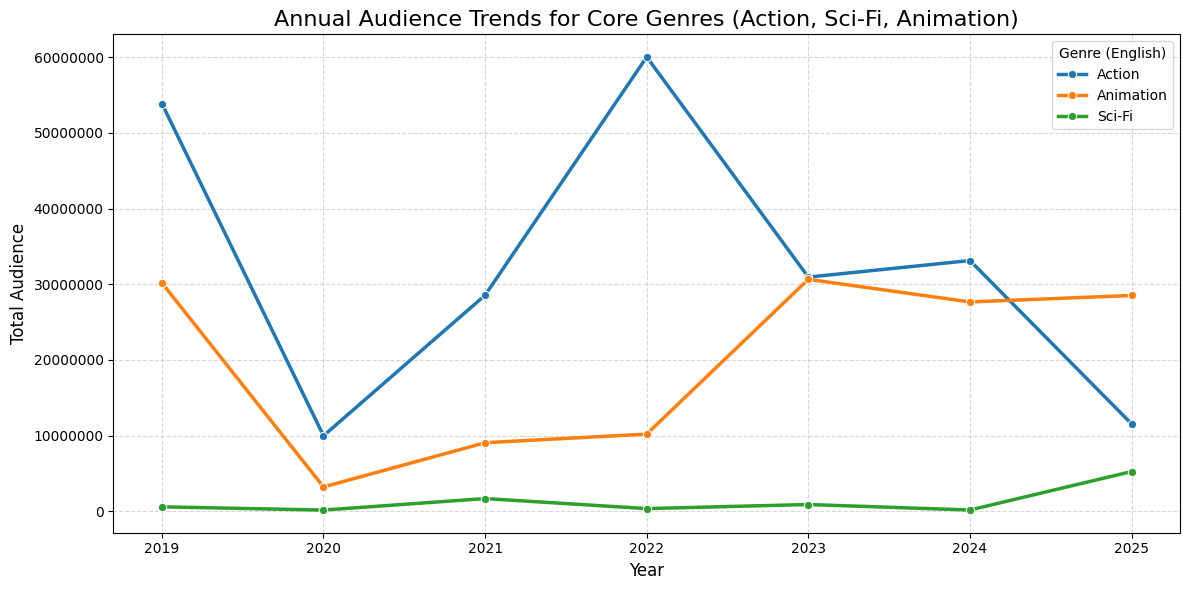

In [8]:
df_audience_by_year_genre = df_movie_genre.groupby(['연도', '장르_영문'])['관객수_명'].sum().reset_index()

core_genres = ['Action', 'Sci-Fi', 'Animation']
df_core_genres = df_audience_by_year_genre[df_audience_by_year_genre['장르_영문'].isin(core_genres)]

plt.figure(figsize=(12, 6))
sns.lineplot(data=df_core_genres, x='연도', y='관객수_명', hue='장르_영문', marker='o', linewidth=2.5)

plt.title('Annual Audience Trends for Core Genres (Action, Sci-Fi, Animation)', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Total Audience', fontsize=12)
plt.ticklabel_format(style='plain', axis='y')

plt.legend(title='Genre (English)', loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [9]:
#연도별 총관객수가 감소하는 추세를 확인, 해당 년도중 가장 총 관객수가 높은 년도는 2022년이고 장르는 액션이다.

In [10]:
#결론: 관람객들이 가장 많이 선호하는 장르는 액션,sf임 -> 그리고 해당 장르 영화 비중 감소 확인됨
#특수관 사용자들이 선호하는 장르가 액션, 애니메이션, sf였다는 인사이트와 연관 지어 설명할 지표
#->특수관 이용비율 조사 필요

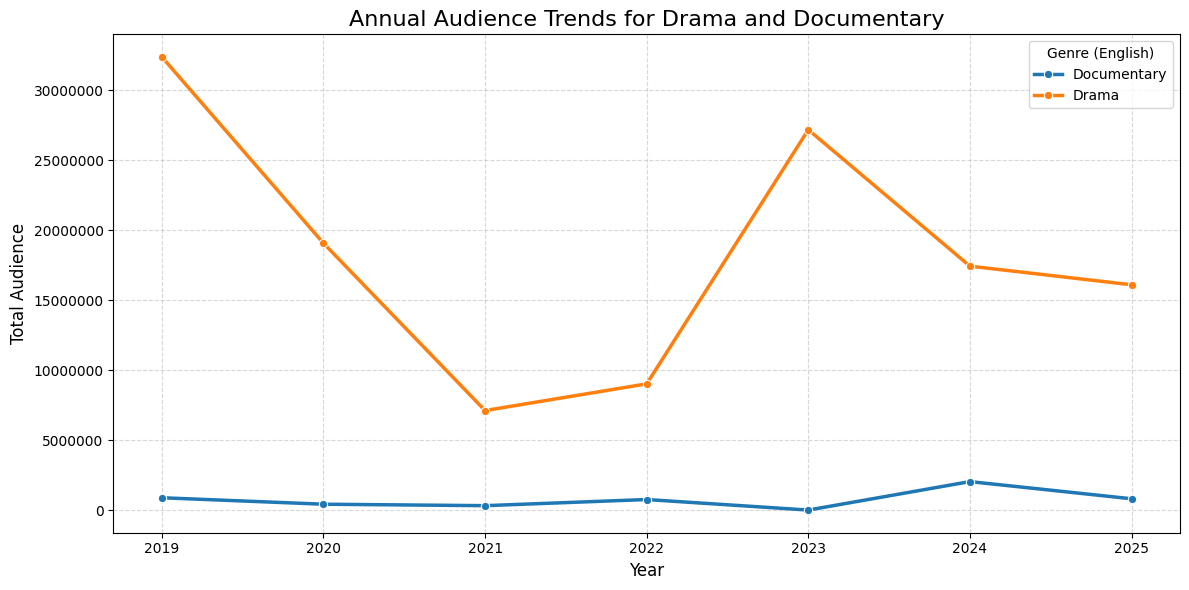

In [12]:
new_genres = ['Drama', 'Documentary']
df_new_genres = df_audience_by_year_genre[df_audience_by_year_genre['장르_영문'].isin(new_genres)]

plt.figure(figsize=(12, 6))
sns.lineplot(data=df_new_genres, x='연도', y='관객수_명', hue='장르_영문', marker='o', linewidth=2.5)

plt.title('Annual Audience Trends for Drama and Documentary', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Total Audience', fontsize=12)
plt.ticklabel_format(style='plain', axis='y')

plt.legend(title='Genre (English)', loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()